Import des bibliothèques et définition des chemins

In [1]:
import os
import random
import shutil
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
random.seed(42)

DATA_ROOT    = "../../dataset"
TRAIN_IMAGES = os.path.join(DATA_ROOT, "train", "images")
TRAIN_LABELS = os.path.join(DATA_ROOT, "train", "labels")
CLASSES = ['Broken', 'Good', 'Lose', 'Uncovered']

# Accepte les deux conventions de split: val/ ou valid/
VAL_SPLIT_NAME = "val" if os.path.isdir(os.path.join(DATA_ROOT, "val")) else "valid"
VAL_DIR = os.path.join(DATA_ROOT, VAL_SPLIT_NAME)

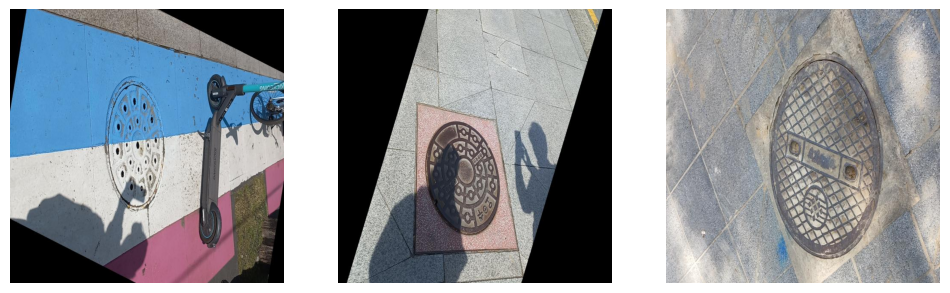

In [2]:
images = [f for f in os.listdir(TRAIN_IMAGES) if f.endswith((".jpg",".png",".jpeg"))]
samples = random.sample(images, min(3, len(images)))

plt.figure(figsize=(12,4))

i = 1
for img_name in samples:
    img = cv2.cvtColor(cv2.imread(os.path.join(TRAIN_IMAGES, img_name)), cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, i)
    plt.imshow(img)
    plt.axis("off")
    i += 1


## Affichage aléatoire d'images avec boîtes englobantes YOLO


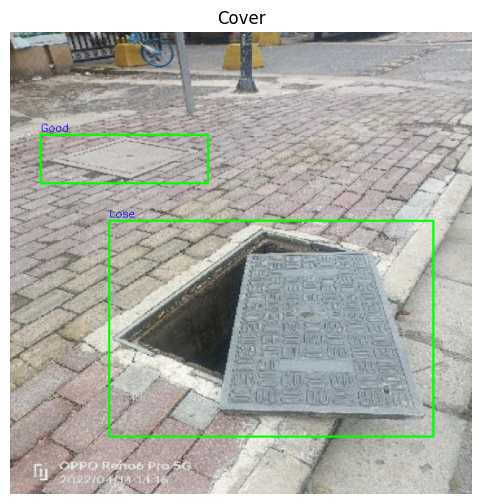

In [4]:
img_name = random.choice(os.listdir(TRAIN_IMAGES))

img_path = os.path.join(TRAIN_IMAGES, img_name)
img_stem, _ = os.path.splitext(img_name)
label_path = os.path.join(TRAIN_LABELS, f"{img_stem}.txt")

img = cv2.imread(img_path)
h, w, _ = img.shape

with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:
    class_id, xc, yc, bw, bh = map(float, line.split())

    x_center = int(xc * w)
    y_center = int(yc * h)
    box_w = int(bw * w)
    box_h = int(bh * h)

    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = CLASSES[int(class_id)]
    cv2.putText(img, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Cover")
plt.show()

## Comptage des images et annotations par split

In [5]:
import os

OUTPUT_ROOT = DATA_ROOT

for split in ["test", "train", VAL_SPLIT_NAME]:
    img_dir = os.path.join(OUTPUT_ROOT, split, "images")
    lbl_dir = os.path.join(OUTPUT_ROOT, split, "labels")

    img_count = len([f for f in os.listdir(img_dir)
                     if f.lower().endswith((".jpg", ".jpeg", ".png"))]) if os.path.isdir(img_dir) else 0

    lbl_count = len([f for f in os.listdir(lbl_dir)
                     if f.endswith(".txt")]) if os.path.isdir(lbl_dir) else 0

    print(f"{split:5s} -> {img_count:4d} images / {lbl_count:4d} labels")

test  ->  252 images /  252 labels
train -> 7222 images / 7222 labels
val   ->  470 images /  470 labels


In [6]:
from collections import defaultdict
import os

class_counts = defaultdict(int)
files_per_class = defaultdict(set)

for lbl_file in os.listdir(TRAIN_LABELS):
    if not lbl_file.endswith(".txt"):
        continue

    with open(os.path.join(TRAIN_LABELS, lbl_file), "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    class_ids_in_file = {int(line.split()[0]) for line in lines}
    for class_id in class_ids_in_file:
        files_per_class[class_id].add(lbl_file)

    for line in lines:
        class_id = int(line.split()[0])
        class_counts[class_id] += 1

print("Objets par classe (annotations):")
for k in sorted(class_counts):
    print(f"- {CLASSES[k]:10s}: {class_counts[k]}")

print("\nImages contenant la classe:")
for k in sorted(files_per_class):
    print(f"- {CLASSES[k]:10s}: {len(files_per_class[k])}")

min_count = min(class_counts.values())
max_count = max(class_counts.values())
imbalance_ratio = max_count / max(1, min_count)
print(f"\nRatio desequilibre max/min: {imbalance_ratio:.2f}x")

if imbalance_ratio > 2.0:
    print("Conseil: activer image_weights=True ou enrichir les classes minoritaires par vraie augmentation.")

Objets par classe (annotations):
- Broken    : 1992
- Good      : 2261
- Lose      : 1923
- Uncovered : 1912

Images contenant la classe:
- Broken    : 1902
- Good      : 1835
- Lose      : 1910
- Uncovered : 1912

Ratio desequilibre max/min: 1.18x


In [7]:
for k in sorted(class_counts):
    print(f"{CLASSES[k]:10s}: {class_counts[k]}")

Broken    : 1992
Good      : 2261
Lose      : 1923
Uncovered : 1912


## Génération du fichier `data.yaml` pour YOLOv8

Ce fichier est lu par Ultralytics lors de l'entraînement pour connaître les chemins et les classes.

In [8]:
import yaml

yaml_content = {
    "path": os.path.abspath(OUTPUT_ROOT),
    "train": "train/images",
    "val": f"{VAL_SPLIT_NAME}/images",
    "nc": len(CLASSES),
    "names": CLASSES,
}

yaml_path = os.path.join(OUTPUT_ROOT, "data.yaml")
os.makedirs(OUTPUT_ROOT, exist_ok=True)
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml cree -> {yaml_path}")
print(open(yaml_path, encoding="utf-8").read())

data.yaml cree -> ../../dataset\data.yaml
names:
- Broken
- Good
- Lose
- Uncovered
nc: 4
path: c:\mes projets\Frouge\Frouge\dataset
train: train/images
val: val/images



## 7. Entraînement YOLOv8

Lance l'entraînement avec le modèle de base `yolov8n.pt`. Les poids seront sauvegardés dans `ml/model/`.

In [ ]:
from ultralytics import YOLO
import os

os.environ["MLFLOW_TRACKING_URI"] = "file:///C:/mlflow"
model = YOLO("yolov8s.pt")

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    lr0=0.005,
    lrf=0.05,
    weight_decay=0.0005,
    cos_lr=True,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    mosaic=0.5,
    mixup=0.1,
    close_mosaic=10,
    project="../models",
    name="yolov8_cover-detector",
    seed=42,
    cache=True,
    workers=4,
    plots=True,
    verbose=True,
    pretrained=True,
    exist_ok=True,
    amp=True,
    save=True,
    save_period=10,
    val=True,
    device=0 if os.getenv("CUDA_VISIBLE_DEVICES", "") != "" else "cpu",
)

print("Entrainement termine. Resultats dans ../models/yolov8_cover-detector")

New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.220  Python-3.13.7 torch-2.9.0+cu128 CPU (Intel Core Ultra 7 165H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../../dataset\data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=yolov8_cover-detector, nbs=64, nms=False, ops

## Évaluation sur le jeu de validation



In [ ]:
MODEL_OUTPUT_DIR = os.path.abspath("../models")
best_weights = os.path.join(MODEL_OUTPUT_DIR, "yolov8_cover-detector", "weights", "best.pt")

if not os.path.isfile(best_weights):
    raise FileNotFoundError(f"best.pt introuvable: {best_weights}")

eval_model = YOLO(best_weights)
metrics = eval_model.val(data=yaml_path, conf=0.30, iou=0.60)

print(f"Poids utilises         : {best_weights}")
print(f"Precision (P)          : {metrics.box.mp:.4f}")
print(f"Rappel (R)             : {metrics.box.mr:.4f}")
print(f"mAP@0.5                : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95           : {metrics.box.map:.4f}")

print("\nPerformance par classe (mAP@0.5:0.95):")
for idx, cls_name in enumerate(CLASSES):
    print(f"- {cls_name:10s}: {metrics.box.maps[idx]:.4f}")

Ultralytics 8.3.220  Python-3.13.7 torch-2.9.0+cu128 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\salma\AppData\Local\Temp\ipykernel_532\1839448012.py:2: SyntaxWarning: invalid escape sequence '\m'
  best_weights = os.path.join(MODEL_OUTPUT_DIR, "C:\mes projets\Frouge\Frouge\ml\models\yolov8_cover-detector", "weights", "best.pt")


Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 172.244.0 MB/s, size: 56.8 KB)
val: Scanning C:\mes projets\Frouge\Frouge\dataset\val\labels.cache... 470 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 470/470 596.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 4.7it/s 6.4s0.2s
                   all        470        502      0.779      0.658      0.746      0.549
                Broken        414        416      0.997      0.746      0.948      0.754
                  Good         60         86      0.561       0.57      0.544      0.345
Speed: 1.6ms preprocess, 7.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\salma\runs\detect\val9
Précision (P)       : 0.7788
Rappel    (R)       : 0.6578
mAP@0.5             : 0.7461
mAP@0.5:0.95        : 0.5494


## Prédictions sur quelques images

Charge les poids `best.pt` et affiche les résultats annotés (boîtes, classes, confiance) sur des images de validation.

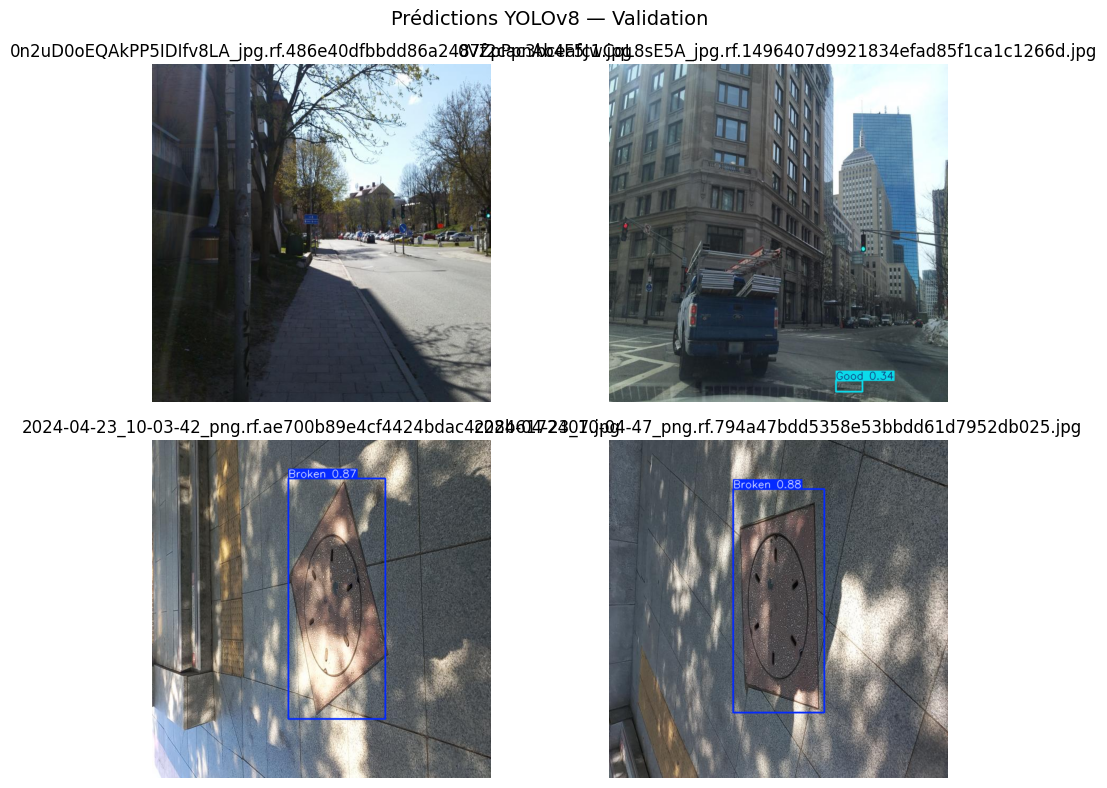

In [ ]:
predict_model = YOLO(best_weights)

val_img_dir = os.path.join(OUTPUT_ROOT, VAL_SPLIT_NAME, "images")

val_images = [
    os.path.join(val_img_dir, f)
    for f in os.listdir(val_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]

predictions = predict_model.predict(
    source=val_images,
    conf=0.35,
    iou=0.60,
    verbose=False
)

n_pred = len(predictions)
cols = 3
rows = (n_pred + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() if n_pred > 1 else [axes]

for i in range(n_pred):
    pred = predictions[i]
    annotated = pred.plot()
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    max_conf = float(pred.boxes.conf.max().item()) if pred.boxes is not None and len(pred.boxes) else 0.0
    axes[i].set_title(f"{os.path.basename(pred.path)} | conf max={max_conf:.2f}")
    axes[i].axis("off")

for i in range(n_pred, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Predictions YOLOv8 - Validation", fontsize=14)
plt.tight_layout()
plt.show()